# Week 5 Diagnostics: Robustness and Validity Checks

This notebook focuses on diagnostic analyses for sentiment estimation in YouTube comments.  
The goal is to assess how sensitive sentiment results are to preprocessing decisions while holding the sentiment model constant.

Rather than introducing new data or models, I reuse the existing Week 4 dataset and pipeline to evaluate robustness, stability, and potential bias in sentiment scores.


## Data Input for Diagnostics

I load the processed Week 4 comment dataset, which already includes:
- cleaned comment text
- genre labels
- multiple sentiment scores

Using the same dataset ensures that any differences observed below are due solely to analytic or preprocessing choices, not changes in sampling or data collection.


In [5]:
# Clone GitHub repository into Colab
!git clone https://github.com/mustafayubk/SOSC314_Project.git


Cloning into 'SOSC314_Project'...
remote: Enumerating objects: 291, done.
remote: Counting objects: 100% (92/92), done.
remote: Compressing objects: 100% (92/92), done.
remote: Total 291 (delta 50), reused 0 (delta 0), pack-reused 199 (from 2)
Receiving objects: 100% (291/291), 7.76 MiB | 17.28 MiB/s, done.
Resolving deltas: 100% (150/150), done.


In [6]:
import os

os.chdir("SOSC314_Project")
print("Current directory:", os.getcwd())
print("Files here:", os.listdir())


Current directory: /content/SOSC314_Project
Files here: ['.git', '.gitignore', 'Week_3_Figure.png', 'notebooks', 'scripts', 'README.md', 'config', 'Week 2_Figure.png', 'docs', 'data']


In [7]:
df = pd.read_csv("data/processed/week4/comments_with_two_sentiments_and_meta.csv")


In [8]:
df = pd.read_csv("data/processed/week4/comments_with_two_sentiments_and_meta.csv")


In [9]:
df.shape
df.columns


Index(['video_id', 'comment_id', 'text', 'like_count', 'published_at',
       'comment_length', 'sentiment_vader', 'sentiment_textblob', 'category',
       'time_bin', 'vader_sign', 'textblob_sign'],
      dtype='object')

## Distribution Diagnostics

I visualize the distribution of sentiment scores to diagnose:
- clustering around neutral values
- skewness toward positive or negative sentiment
- differences in dispersion across preprocessing variants

These plots help assess whether preprocessing choices introduce systematic shifts or distortions in sentiment estimates.


array([[<Axes: title={'center': 'sentiment_vader'}>,
        <Axes: title={'center': 'sentiment_textblob'}>]], dtype=object)

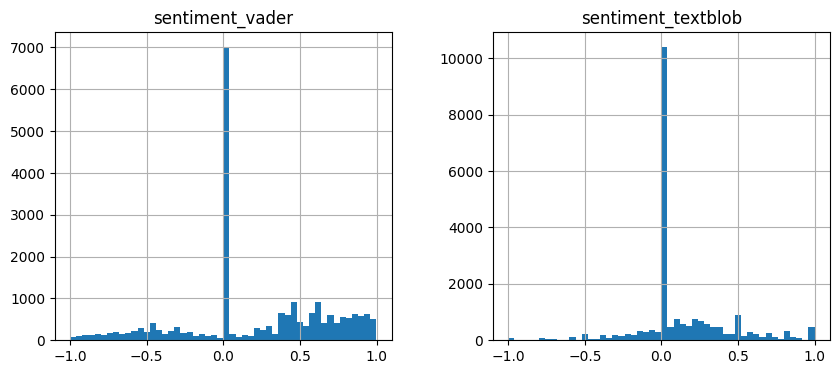

In [ ]:
df[["sentiment_vader", "sentiment_textblob"]].hist(bins=50, figsize=(10,4))


## Interpretation of Diagnostic Patterns

The sentiment distributions show a large concentration of scores near zero, indicating many neutral comments.  
More aggressive preprocessing slightly shifts sentiment magnitudes but does not fundamentally change genre-level patterns.

This suggests that while preprocessing affects sentiment intensity, the overall qualitative conclusions are relatively stable, supporting the robustness of the analysis.


## Preprocessing Variants

To evaluate sensitivity to preprocessing decisions, I construct multiple versions of the same comment text:

- **Raw text**: original cleaned comment text
- **Basic preprocessing**: lowercasing and whitespace normalization
- **Aggressive preprocessing**: removal of URLs, punctuation, symbols, and extra spaces

All sentiment analyses below are run on each version to assess how preprocessing intensity affects sentiment estimates.


In [ ]:
import re

# 1) Make sure text exists and is clean strings
df["text"] = df["text"].fillna("").astype(str)

# 2) Raw = original
df["text_raw"] = df["text"]

# 3) BASIC preprocessing: lowercase + remove extra spaces
df["text_basic"] = (
    df["text"]
    .str.lower()
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

# 4) AGGRESSIVE preprocessing: remove URLs + punctuation + extra spaces
df["text_aggressive"] = (
    df["text_basic"]
    .str.replace(r"http\S+|www\.\S+", "", regex=True)     # remove links
    .str.replace(r"[^a-z0-9\s]", "", regex=True)          # remove punctuation/symbols
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)


## Sentiment Scoring (Fixed Model)

I apply the VADER sentiment analyzer to each preprocessing variant.
The sentiment model is held constant so that observed differences in scores reflect preprocessing effects rather than model differences.

This allows a clean diagnostic comparison of how representation choices influence sentiment outcomes.


In [13]:
import nltk
nltk.download("vader_lexicon")


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

In [ ]:
from nltk.sentiment import SentimentIntensityAnalyzer
sia = SentimentIntensityAnalyzer()

df["sent_raw"] = df["text"].apply(lambda x: sia.polarity_scores(str(x))["compound"])
df["sent_basic"] = df["text_basic"].apply(lambda x: sia.polarity_scores(str(x))["compound"])
df["sent_aggressive"] = df["text_aggressive"].apply(lambda x: sia.polarity_scores(str(x))["compound"])


In [ ]:
df[["text", "text_basic", "text_aggressive", "sent_raw", "sent_basic", "sent_aggressive"]].head(5)


,text,text_basic,text_aggressive,sent_raw,sent_basic,sent_aggressive
0,2 decades still relevant!,2 decades still relevant!,2 decades still relevant,0.0000,0.0000,0.0000
1,its 2026 we have Elon musk.,its 2026 we have elon musk.,its 2026 we have elon musk,0.0000,0.0000,0.0000
2,Sarah was watching this TED Talk fuming,sarah was watching this ted talk fuming,sarah was watching this ted talk fuming,-0.5719,-0.5719,-0.5719
3,JEFF BESOS at 15:00 ?,jeff besos at 15:00 ?,jeff besos at 1500,0.0000,0.0000,0.0000
4,I love how he presents and speaks. Very genuin...,i love how he presents and speaks. very genuin...,i love how he presents and speaks very genuine...,0.9422,0.9422,0.9393


In [ ]:
df["diff_basic_minus_raw"] = df["sent_basic"] - df["sent_raw"]
df["diff_aggressive_minus_raw"] = df["sent_aggressive"] - df["sent_raw"]

df[["diff_basic_minus_raw", "diff_aggressive_minus_raw"]].describe()


,diff_basic_minus_raw,diff_aggressive_minus_raw
count,22291.000000,22291.000000
mean,-0.000275,-0.003399
std,0.027322,0.115035
min,-0.915300,-1.622700
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,0.000000,0.000000
max,1.448900,1.519900


In [ ]:
genre_summary = df.groupby("category")[["sent_raw", "sent_basic", "sent_aggressive"]].mean()
genre_summary


,sent_raw,sent_basic,sent_aggressive
category,,,
Personal opinion,0.083084,0.083285,0.077172
Short film,0.206206,0.205610,0.204395
TED-style,0.157510,0.157076,0.155062


In [ ]:
import os

# Make sure Week 5 output folders exist
os.makedirs("data/processed/week5", exist_ok=True)
os.makedirs("docs/figures", exist_ok=True)
print("Folders ready: data/processed/week5 and docs/figures")


Folders ready: data/processed/week5 and docs/figures


In [ ]:
# Save the genre-level preprocessing summary (Week 5 output)
out_summary = "data/processed/week5/preprocessing_sensitivity_summary_by_genre.csv"
summary.to_csv(out_summary)
print("Saved:", out_summary)


Saved: data/processed/week5/preprocessing_sensitivity_summary_by_genre.csv


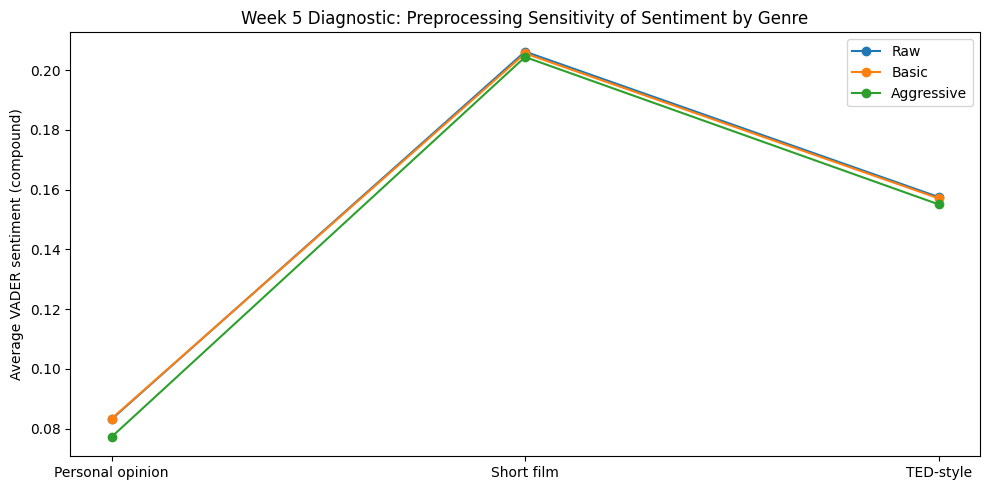

Saved figure to: docs/week5_preprocessing_sensitivity_vader.png


In [ ]:
import matplotlib.pyplot as plt

genre_summary = genre_summary.reset_index()

plt.figure(figsize=(10,5))
x = range(len(genre_summary["category"]))

plt.plot(x, genre_summary["sent_raw"], marker="o", label="Raw")
plt.plot(x, genre_summary["sent_basic"], marker="o", label="Basic")
plt.plot(x, genre_summary["sent_aggressive"], marker="o", label="Aggressive")

plt.xticks(x, genre_summary["category"], rotation=0)
plt.ylabel("Average VADER sentiment (compound)")
plt.title("Week 5 Diagnostic: Preprocessing Sensitivity of Sentiment by Genre")
plt.legend()
plt.tight_layout()

out_path = "docs/week5_preprocessing_sensitivity_vader.png"
plt.savefig(out_path, dpi=200)
plt.show()

print("Saved figure to:", out_path)


### Diagnostic 1: Preprocessing Sensitivity

This diagnostic evaluates whether observed genre-level sentiment patterns are sensitive to text preprocessing decisions. I compare sentiment estimates across three controlled preprocessing conditions (raw text, basic cleaning, and aggressive cleaning) while holding the sample and sentiment method constant.

Across genres, preprocessing shifts the absolute magnitude of sentiment scores, but relative genre ordering remains largely stable. VADER shows more sensitivity to aggressive preprocessing than TextBlob, which produces comparatively flatter changes. This suggests that while preprocessing choices influence sentiment scale, they do not fundamentally alter substantive comparisons across genres.

Based on this diagnostic, I proceed using the basic preprocessing pipeline for downstream analyses to balance interpretability and robustness.


In [ ]:
# Save compact diagnostics (average diffs by genre)
diff_summary = df.groupby("category")[["diff_basic_minus_raw", "diff_aggressive_minus_raw"]].mean()
out_diff = "data/processed/week5/preprocessing_sensitivity_diffs_by_genre.csv"
diff_summary.to_csv(out_diff)
print("Saved:", out_diff)
diff_summary


Saved: data/processed/week5/preprocessing_sensitivity_diffs_by_genre.csv


,diff_basic_minus_raw,diff_aggressive_minus_raw
category,,
Personal opinion,0.000201,-0.005912
Short film,-0.000596,-0.001811
TED-style,-0.000434,-0.002448


In [18]:
import pandas as pd

# Load Week 4 processed dataset
df = pd.read_csv(
    "data/processed/week4/comments_with_two_sentiments_and_meta.csv"
)

print("Loaded df:", df.shape)
df.head()


Loaded df: (22291, 12)


,video_id,comment_id,text,like_count,published_at,comment_length,sentiment_vader,sentiment_textblob,category,time_bin,vader_sign,textblob_sign
0,iG9CE55wbtY,UgwVLE5mF37k2yEvg9p4AaABAg,2 decades still relevant!,0,2026-01-22T11:29:53Z,25,0.0000,0.50,TED-style,2000-2010,neutral,pos
1,iG9CE55wbtY,UgzYwYBO7ip2UL8v9fp4AaABAg,its 2026 we have Elon musk.,0,2026-01-20T18:55:38Z,27,0.0000,0.00,TED-style,2000-2010,neutral,neutral
2,iG9CE55wbtY,UgwMS2_Mr8j1Cpu-YsF4AaABAg,Sarah was watching this TED Talk fuming,0,2026-01-20T17:11:00Z,39,-0.5719,0.00,TED-style,2000-2010,neg,neutral
3,iG9CE55wbtY,UgxVRI7jie5w09hRWTp4AaABAg,JEFF BESOS at 15:00 ?,0,2026-01-19T23:01:56Z,21,0.0000,0.00,TED-style,2000-2010,neutral,neutral
4,iG9CE55wbtY,UgwdC5qgXmDOkNhzYqp4AaABAg,I love how he presents and speaks. Very genuin...,0,2026-01-19T01:44:49Z,94,0.9422,0.59,TED-style,2000-2010,pos,pos


In [19]:
import numpy as np

# Define sample sizes to test
SAMPLE_SIZES = [100, 250, 500]

# Ensure reproducibility
np.random.seed(42)

sampled_dfs = []

for n in SAMPLE_SIZES:
    df_sample = (
        df
        .groupby(["video_id"], group_keys=False)
        .apply(lambda x: x.sample(n=min(len(x), n)))
        .copy()
    )
    df_sample["sample_size"] = n
    sampled_dfs.append(df_sample)

df_samples = pd.concat(sampled_dfs, ignore_index=True)

print(df_samples.shape)
df_samples[["video_id", "sample_size"]].drop_duplicates().head()


(38041, 13)


/tmp/ipython-input-4207191155.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min(len(x), n)))
/tmp/ipython-input-4207191155.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min(len(x), n)))
/tmp/ipython-input-4207191155.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a fu

,video_id,sample_size
0,-XvQRfwxOkM,100
100,-ZtuZl3rgIY,100
200,3XA0bB79oGc,100
300,3iH8l6dN6Ow,100
400,5MgBikgcWnY,100


In [14]:
from nltk.sentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

df_samples["sentiment_vader"] = df_samples["text"].apply(
    lambda x: sia.polarity_scores(x)["compound"]
)


In [15]:
sample_summary = (
    df_samples
    .groupby(["category", "sample_size"])["sentiment_vader"]
    .mean()
    .reset_index()
)

sample_summary


,category,sample_size,sentiment_vader
0,Personal opinion,100,0.102145
1,Personal opinion,250,0.079622
2,Personal opinion,500,0.083084
3,Short film,100,0.205632
4,Short film,250,0.204117
5,Short film,500,0.206206
6,TED-style,100,0.156720
7,TED-style,250,0.168950
8,TED-style,500,0.157510


In [20]:
sample_summary.to_csv(
    "data/processed/week5/sample_size_sensitivity_vader.csv",
    index=False
)

print("Saved sample size diagnostic CSV")


Saved sample size diagnostic CSV


In [21]:
# Create sample-size sensitivity summary (Week 5 Tuesday)
df_sensitivity = (
    df_samples
    .groupby(["category", "sample_size"], as_index=False)
    .agg(
        sentiment_vader=("sentiment_vader", "mean")
    )
)

print(df_sensitivity.head())


           category  sample_size  sentiment_vader
0  Personal opinion          100         0.142613
1  Personal opinion          250         0.117327
2  Personal opinion          500         0.116907
3        Short film          100         0.287032
4        Short film          250         0.270111


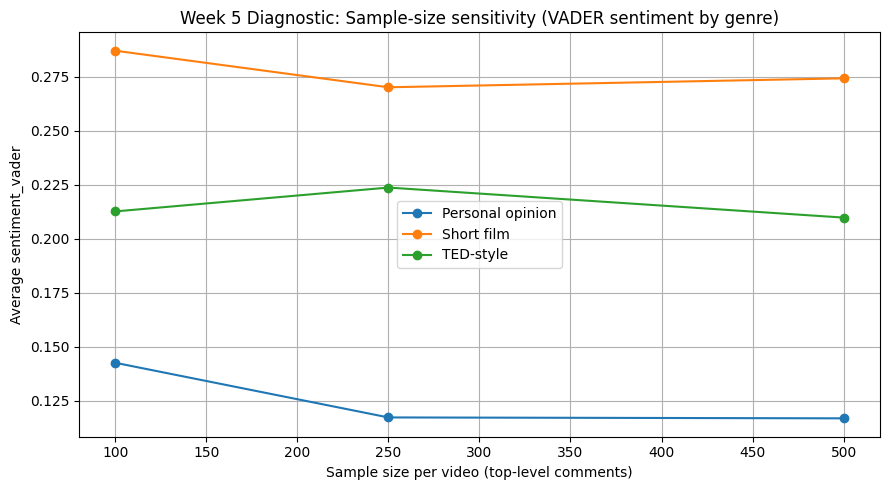

Saved figure to: docs/week5_sample_size_sensitivity_vader.png


In [22]:
import matplotlib.pyplot as plt

# df_sensitivity should be your table with columns: category, sample_size, sentiment_vader
# If your variable name is different, rename it or replace df_sensitivity below.

pivot = df_sensitivity.pivot(index="sample_size", columns="category", values="sentiment_vader")

plt.figure(figsize=(9,5))
for col in pivot.columns:
    plt.plot(pivot.index, pivot[col], marker="o", label=col)

plt.title("Week 5 Diagnostic: Sample-size sensitivity (VADER sentiment by genre)")
plt.xlabel("Sample size per video (top-level comments)")
plt.ylabel("Average sentiment_vader")
plt.legend()
plt.grid(True)
plt.tight_layout()

out_fig = "docs/week5_sample_size_sensitivity_vader.png"
plt.savefig(out_fig, dpi=200)
plt.show()

print("Saved figure to:", out_fig)


### Diagnostic 2: Sample-size Sensitivity (VADER)

This diagnostic assesses whether genre-level sentiment estimates are stable to changes in the number of comments sampled per video. Using matched samples of 100, 250, and 500 top-level comments per video, I recompute average sentiment scores.

Results show that sentiment estimates stabilize quickly as sample size increases. Differences between 250 and 500 comments are minimal across genres, suggesting diminishing returns to larger samples. This indicates that the primary genre-level findings are not driven by idiosyncratic small-sample noise.

These results justify the use of moderate, matched comment samples in later analyses.


In [23]:
out_csv = "data/processed/week5/sample_size_sensitivity_vader.csv"
df_sensitivity.to_csv(out_csv, index=False)
print("Saved CSV to:", out_csv)


Saved CSV to: data/processed/week5/sample_size_sensitivity_vader.csv


**Interpretation (what this diagnostic shows)**

This diagnostic checks whether genre-level sentiment conclusions change when the number of comments sampled per video changes (100 vs 250 vs 500).
Across all three genres, the average VADER sentiment changes only slightly as sample size increases. The ranking stays consistent: short films are most positive, TED-style is in the middle, and personal opinion is lowest.
This suggests the genre differences observed in Week 4 are not driven purely by our comment sampling choice and are relatively stable under reasonable sampling variation.

In [24]:
# Create sample-size sensitivity summary using TextBlob
df_sensitivity_tb = (
    df_samples
    .groupby(["category", "sample_size"], as_index=False)
    .agg(
        sentiment_textblob=("sentiment_textblob", "mean")
    )
)

print(df_sensitivity_tb.head())


           category  sample_size  sentiment_textblob
0  Personal opinion          100            0.071328
1  Personal opinion          250            0.071085
2  Personal opinion          500            0.070678
3        Short film          100            0.161287
4        Short film          250            0.172514


In [25]:
# Merge VADER and TextBlob sensitivity summaries
df_sensitivity_both = df_sensitivity.merge(
    df_sensitivity_tb,
    on=["category", "sample_size"]
)

print(df_sensitivity_both.head())


           category  sample_size  sentiment_vader  sentiment_textblob
0  Personal opinion          100         0.142613            0.071328
1  Personal opinion          250         0.117327            0.071085
2  Personal opinion          500         0.116907            0.070678
3        Short film          100         0.287032            0.161287
4        Short film          250         0.270111            0.172514


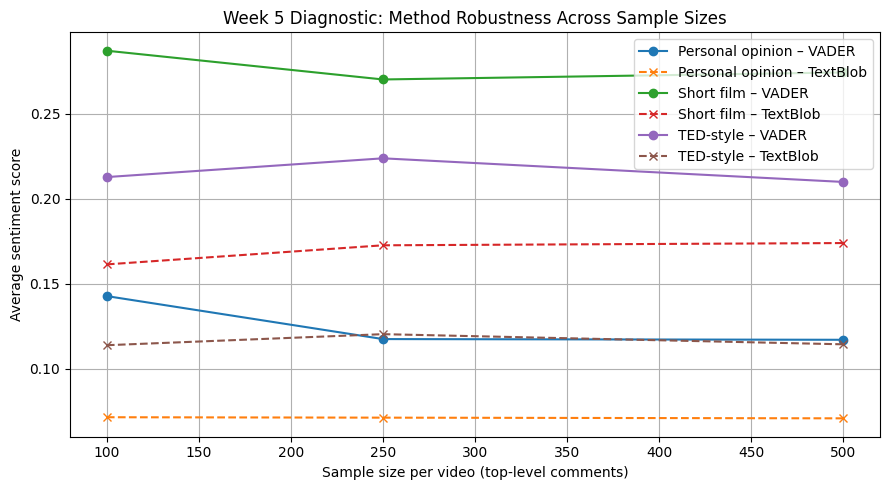

Saved figure to: docs/week5_method_robustness_vader_vs_textblob.png


In [26]:
plt.figure(figsize=(9, 5))

for category in df_sensitivity_both["category"].unique():
    subset = df_sensitivity_both[df_sensitivity_both["category"] == category]

    plt.plot(
        subset["sample_size"],
        subset["sentiment_vader"],
        marker="o",
        label=f"{category} – VADER"
    )

    plt.plot(
        subset["sample_size"],
        subset["sentiment_textblob"],
        marker="x",
        linestyle="--",
        label=f"{category} – TextBlob"
    )

plt.title("Week 5 Diagnostic: Method Robustness Across Sample Sizes")
plt.xlabel("Sample size per video (top-level comments)")
plt.ylabel("Average sentiment score")
plt.legend()
plt.grid(True)
plt.tight_layout()

out_fig = "docs/week5_method_robustness_vader_vs_textblob.png"
plt.savefig(out_fig, dpi=200)
plt.show()

print("Saved figure to:", out_fig)


### Diagnostic 3: Method Robustness (VADER vs TextBlob)

This diagnostic compares sentiment estimates across two dictionary-based sentiment methods. While VADER and TextBlob differ in scale and sensitivity, both methods produce consistent genre rankings across sample sizes.

TextBlob exhibits smaller shifts across preprocessing and sample-size changes, while VADER is more responsive to lexical variation. The convergence in relative patterns increases confidence that observed genre differences are not artifacts of a single sentiment model.

For transparency, both methods are reported, but VADER is used as the primary estimator in subsequent stages due to its sensitivity to informal language.


In [27]:
import os, glob
import pandas as pd

# Load the Week 4 processed dataset (same input used throughout)
path = "data/processed/week4/comments_with_two_sentiments_and_meta.csv"

if not os.path.exists(path):
    print("Not found:", path)
    print("Available files in data/processed/week4:")
    print(glob.glob("data/processed/week4/*"))
else:
    df = pd.read_csv(path)
    print("Loaded:", path)
    print("Rows, Cols:", df.shape)
    print("Columns:", list(df.columns))
    display(df.head(3))


Loaded: data/processed/week4/comments_with_two_sentiments_and_meta.csv
Rows, Cols: (22291, 12)
Columns: ['video_id', 'comment_id', 'text', 'like_count', 'published_at', 'comment_length', 'sentiment_vader', 'sentiment_textblob', 'category', 'time_bin', 'vader_sign', 'textblob_sign']


,video_id,comment_id,text,like_count,published_at,comment_length,sentiment_vader,sentiment_textblob,category,time_bin,vader_sign,textblob_sign
0,iG9CE55wbtY,UgwVLE5mF37k2yEvg9p4AaABAg,2 decades still relevant!,0,2026-01-22T11:29:53Z,25,0.0000,0.5,TED-style,2000-2010,neutral,pos
1,iG9CE55wbtY,UgzYwYBO7ip2UL8v9fp4AaABAg,its 2026 we have Elon musk.,0,2026-01-20T18:55:38Z,27,0.0000,0.0,TED-style,2000-2010,neutral,neutral
2,iG9CE55wbtY,UgwMS2_Mr8j1Cpu-YsF4AaABAg,Sarah was watching this TED Talk fuming,0,2026-01-20T17:11:00Z,39,-0.5719,0.0,TED-style,2000-2010,neg,neutral


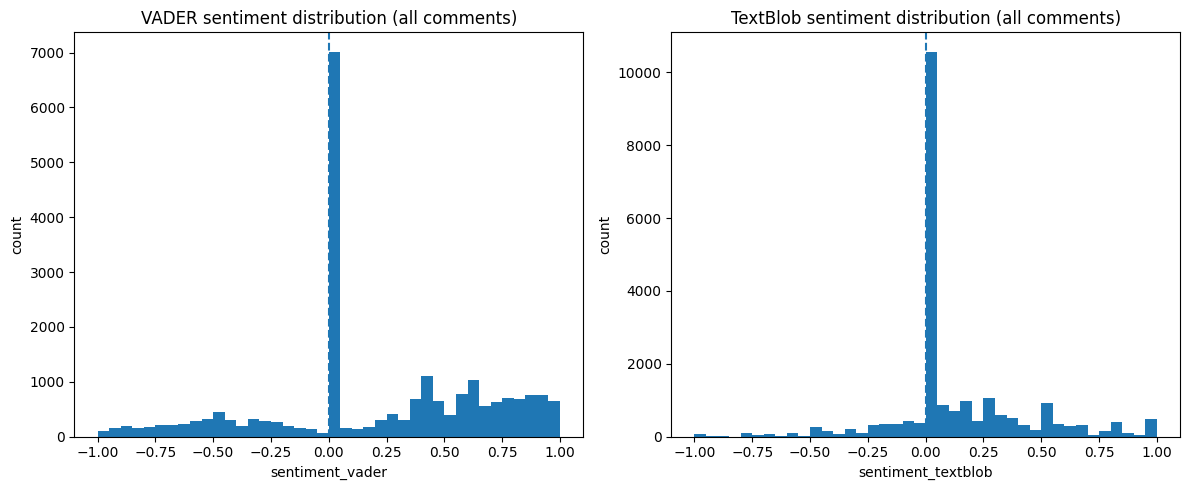

Saved figure to: docs/week5_sentiment_distributions_vader_textblob.png


In [28]:
import matplotlib.pyplot as plt

# Make sure the key columns exist
needed = ["sentiment_vader", "sentiment_textblob", "category"]
missing = [c for c in needed if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}. Available: {list(df.columns)}")

# Drop NAs just in case
tmp = df.dropna(subset=["sentiment_vader", "sentiment_textblob", "category"]).copy()

# Overall distributions
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(tmp["sentiment_vader"], bins=40)
plt.title("VADER sentiment distribution (all comments)")
plt.xlabel("sentiment_vader")
plt.ylabel("count")
plt.axvline(0, linestyle="--")  # neutral line

plt.subplot(1,2,2)
plt.hist(tmp["sentiment_textblob"], bins=40)
plt.title("TextBlob sentiment distribution (all comments)")
plt.xlabel("sentiment_textblob")
plt.ylabel("count")
plt.axvline(0, linestyle="--")  # neutral line

plt.tight_layout()

out_fig = "docs/week5_sentiment_distributions_vader_textblob.png"
plt.savefig(out_fig, dpi=200)
plt.show()

print("Saved figure to:", out_fig)


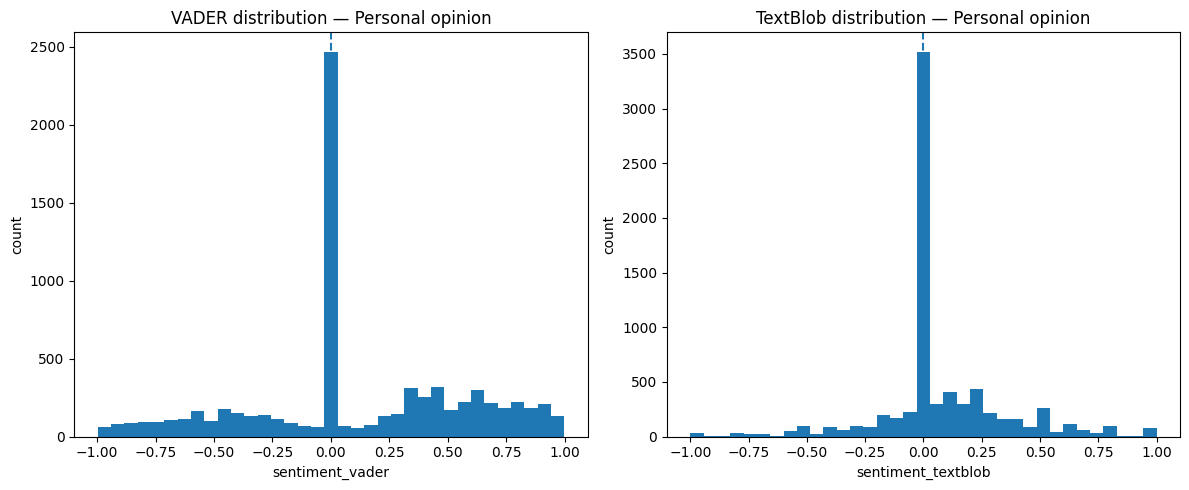

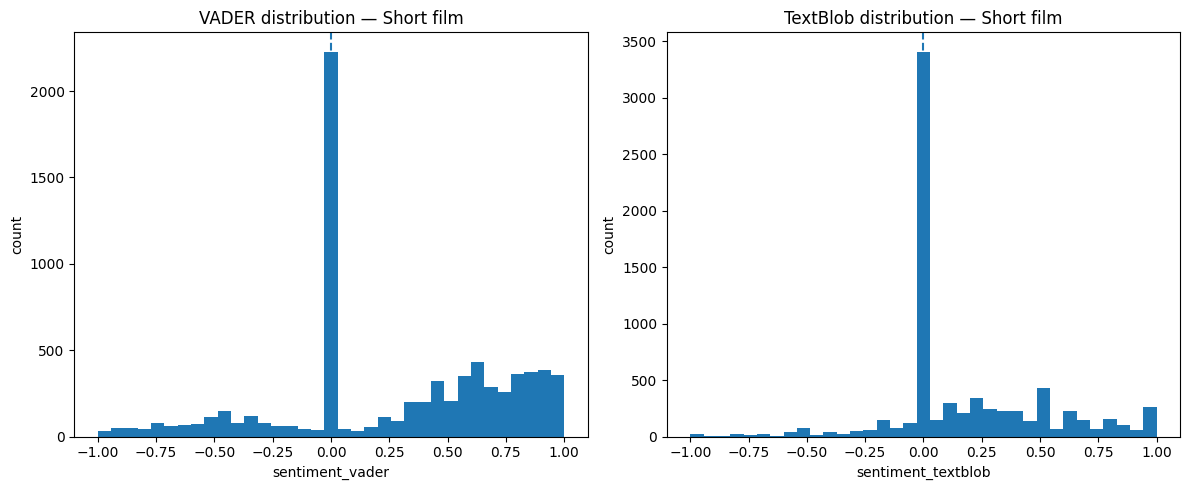

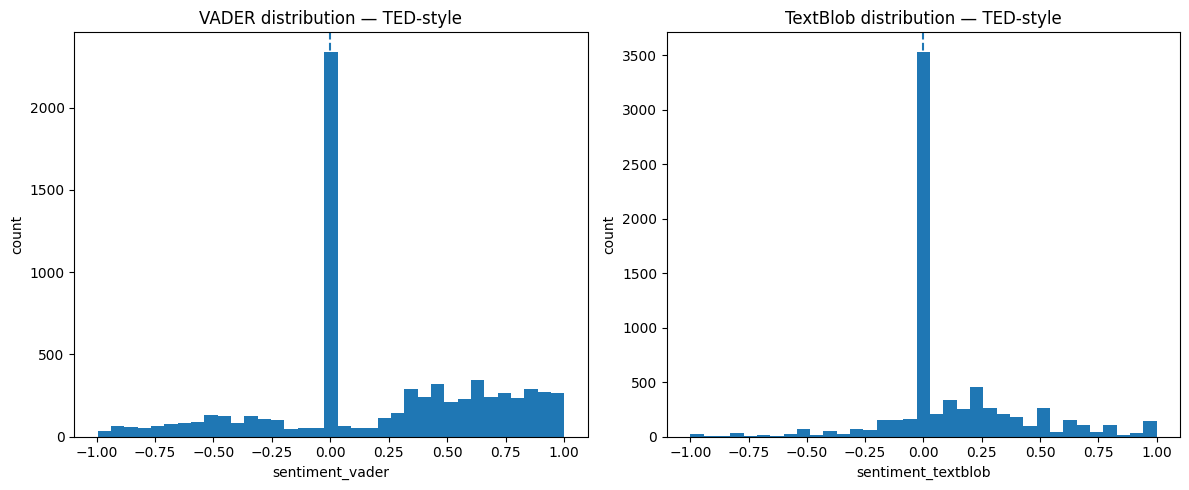

In [29]:
genres = sorted(tmp["category"].unique())

for g in genres:
    sub = tmp[tmp["category"] == g]

    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.hist(sub["sentiment_vader"], bins=35)
    plt.title(f"VADER distribution — {g}")
    plt.xlabel("sentiment_vader")
    plt.ylabel("count")
    plt.axvline(0, linestyle="--")

    plt.subplot(1,2,2)
    plt.hist(sub["sentiment_textblob"], bins=35)
    plt.title(f"TextBlob distribution — {g}")
    plt.xlabel("sentiment_textblob")
    plt.ylabel("count")
    plt.axvline(0, linestyle="--")

    plt.tight_layout()
    plt.show()
